# 💬 Amazon Product Review Sentiment Analysis:
## From Classical Machine Learning to Transformer Fine-Tuning

Classifying Amazon customer reviews into **positive**, **neutral**, and **negative** sentiment using **Natural Language Processing (NLP)**, traditional machine learning models, and transformer-based deep learning.

This project explores sentiment classification using both **classical NLP techniques (TF-IDF + Machine Learning)** and **transformer-based transfer learning (DistilBERT Fine-Tuning)** to compare performance and contextual understanding.

# 📌 Project Information

**Project Type:**  
Natural Language Processing (NLP) / Multi-Class Text Classification / Transformer Fine-Tuning

**Industry:**  
E-Commerce / Customer Experience / Customer Feedback Analytics

**Dataset:**  
Amazon Product Reviews Dataset

**Goal:**  
Build and compare multiple sentiment classification approaches for Amazon customer reviews, ranging from classical machine learning models (**TF-IDF + Logistic Regression / SVM**) to transformer-based deep learning models (**DistilBERT Fine-Tuning**).

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Natural Language Processing (NLP)
- TF-IDF Vectorization
- Logistic Regression
- Linear Support Vector Machine (SVM)
- Hugging Face Transformers
- DistilBERT
- Google Colab

# 📌 Project Overview

Customer reviews are a valuable source of feedback for e-commerce businesses.

However, manually reading thousands of customer reviews is not scalable. Sentiment analysis helps businesses automatically understand whether customer feedback is **positive**, **neutral**, or **negative**, enabling faster decision-making and better customer experience management.

In this project, we build an **NLP sentiment analysis pipeline** that transforms raw customer review text into machine-readable numerical representations and trains multiple classification models to predict customer sentiment.

The project begins with **traditional NLP techniques using TF-IDF vectorization and classical machine learning models as baselines**. We then extend the analysis using **transformer-based transfer learning through DistilBERT fine-tuning** to evaluate whether contextual language understanding improves sentiment classification performance.

# ❓ Business Problem

E-commerce businesses receive large volumes of customer reviews every day.

Without an automated sentiment classification system, it becomes difficult to quickly identify:

- Satisfied customers
- Dissatisfied customers
- Neutral or mixed feedback
- Product issues that may require attention
- Customer perception trends across products

Additionally, customer reviews often contain **mixed or ambiguous sentiment**, making manual interpretation inconsistent and difficult to scale.

### The Challenge

Can we build a machine learning model that automatically classifies Amazon customer reviews as:

- Positive
- Neutral
- Negative

based only on review text?

This is a **supervised NLP multi-class text classification problem**.

# 🎯 Project Objectives

The main objective of this project is to build and compare sentiment classification models using Amazon customer reviews.

By the end of this project, we aim to:

- Load and understand the Amazon reviews dataset
- Create sentiment labels from review scores
- Analyze sentiment distribution
- Clean and preprocess customer review text
- Convert text into numerical representations using TF-IDF
- Build baseline machine learning models
- Improve feature representation using bigrams
- Train advanced classical ML models (Linear SVM)
- Prepare transformer inputs using tokenization and attention masks
- Fine-tune a pretrained DistilBERT transformer model
- Evaluate model performance using classification metrics
- Analyze model errors using confusion matrix
- Compare traditional ML approaches with transformer-based NLP
- Investigate challenges in neutral sentiment classification
- Translate technical findings into business insights

# ⚙️ Machine Learning Pipeline

Business Problem Definition  
↓  
Dataset Loading  
↓  
Data Understanding  
↓  
Sentiment Label Creation  
↓  
Exploratory Data Analysis (EDA)  
↓  
Text Preprocessing  
↓  
TF-IDF Vectorization  
↓  
Baseline Model Training  
(Logistic Regression)  
↓  
Feature Engineering  
(Bigrams)  
↓  
Advanced Classical Models  
(Linear SVM)  
↓  
Transformer Preparation  
(Tokenization + Attention Masks)  
↓  
DistilBERT Fine-Tuning  
↓  
Model Evaluation  
↓  
Confusion Matrix & Error Analysis  
↓  
Model Comparison  
↓  
Business Insights & Final Conclusion

# 📚 Import Libraries & Load Dataset

In this step, we import the required Python libraries and load the customer reviews dataset from Google Drive.

Before performing any cleaning, analysis, or modeling, we need to make sure the dataset is loaded correctly and ready for initial inspection.

In [1]:
# Import main libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load dataset

file_path = "/content/drive/MyDrive/Reviews.csv"

df = pd.read_csv(file_path)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# 🔍 Data Understanding

Before preprocessing or modeling, we first inspect the dataset structure.

This step helps us understand:

- Number of rows and columns
- Available features
- Data types
- Missing values
- Duplicate records

Although the dataset contains many columns, the main columns needed for sentiment analysis are:

- `Text`: the full customer review
- `Score`: the review rating from 1 to 5

In [4]:
# Basic dataset inspection

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:")
print(df.duplicated().sum())

Dataset Shape: (568454, 10)

Column Names:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)


# 🔍 Understanding Review Scores

Before creating sentiment labels, we first inspect the review score values.

The goal is to verify:

- Minimum score
- Maximum score
- Score distribution
- Whether unexpected values exist

This helps ensure the sentiment mapping logic is valid.

In [5]:
# Review score statistics

df['Score'].describe()

,Score
count,568454.000000
mean,4.183199
std,1.310436
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [6]:
# Unique score values

df['Score'].value_counts().sort_index()

,count
Score,
1,52268
2,29769
3,42640
4,80655
5,363122


# 🏷️ Creating Sentiment Labels

The original dataset contains review ratings from 1 to 5.

To convert this problem into a sentiment classification task, we create sentiment labels based on review scores:

- **1–2 → Negative**
- **3 → Neutral**
- **4–5 → Positive**

Only the relevant columns for NLP modeling are retained:

- `Text` → customer review
- `sentiment` → target label

In [7]:
# Keep only required columns

df = df[['Text', 'Score']]


# Create sentiment labels from score

def create_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'


df['sentiment'] = df['Score'].apply(create_sentiment)


# Keep only final columns

df = df[['Text', 'sentiment']]


# Display dataset preview

df.head()

,Text,sentiment
0,I have bought several of the Vitality canned d...,positive
1,Product arrived labeled as Jumbo Salted Peanut...,negative
2,This is a confection that has been around a fe...,positive
3,If you are looking for the secret ingredient i...,negative
4,Great taffy at a great price. There was a wid...,positive


# ⚖️ Creating a Balanced Dataset

The original dataset is highly imbalanced, with positive reviews significantly outnumbering neutral and negative reviews.

To reduce model bias and improve fairness across sentiment classes, we create a balanced dataset by sampling an equal number of reviews from each sentiment category.

Selected sample size:

- 10,000 Positive reviews
- 10,000 Neutral reviews
- 10,000 Negative reviews

Final dataset size: **30,000 reviews**

In [8]:
# Create balanced dataset

positive_sample = df[df['sentiment'] == 'positive'].sample(
    n=10000,
    random_state=42
)

neutral_sample = df[df['sentiment'] == 'neutral'].sample(
    n=10000,
    random_state=42
)

negative_sample = df[df['sentiment'] == 'negative'].sample(
    n=10000,
    random_state=42
)

# Combine samples

df = pd.concat([
    positive_sample,
    neutral_sample,
    negative_sample
])

# Shuffle dataset

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)

df['sentiment'].value_counts()

(30000, 2)


,count
sentiment,
positive,10000
negative,10000
neutral,10000


# 📊 Exploratory Data Analysis (EDA)

Before preprocessing and model training, we explore the dataset to better understand customer reviews.

At this stage, we analyze:

- Sentiment distribution
- Review text examples
- Review length patterns

This helps us understand the nature of the text before NLP preprocessing.

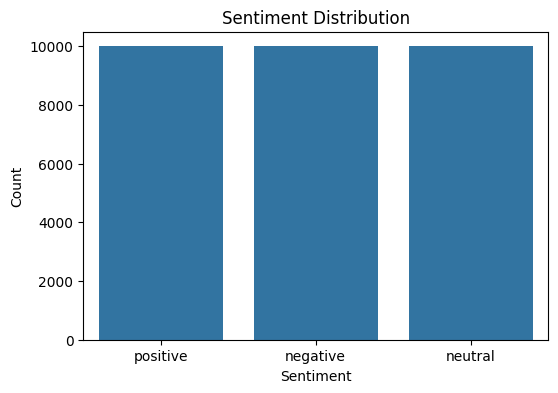

In [9]:
# Visualize sentiment distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='sentiment')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [10]:
# Display random customer reviews

for i in range(5):
    print(f"Review {i+1}")
    print(df['Text'].sample(1).values[0])
    print("-" * 100)

Review 1
I was very disappointed in this purchase.  I was use to getting 3 16ct packs for this price of $23.99, not just 1 pack.  I returned this item for a refund.
----------------------------------------------------------------------------------------------------
Review 2
We have a corgi and this kibble is one of the only two things that the breeder recommended. Unfortunately our dog does not like this food. He would NEVER eat a pellet on its own. We always have to mix it with real food and even then he sometimes refuses to eat it. On top of that none of the pet shops in our area carry this food so overall big PITA.<br /><br />We are still ordering from Amazon but looking for an alternative.
----------------------------------------------------------------------------------------------------
Review 3
Ordered on January 8th, but as of February 10th, I have still not received this product.
--------------------------------------------------------------------------------------------------

## 📏 Review Length Analysis

Before text preprocessing, we analyze review length.

This helps us understand:

- Average review length
- Short vs long reviews
- Whether extreme review lengths exist

This is important for NLP preprocessing decisions.

In [11]:
# Create review length feature

df['review_length'] = df['Text'].apply(len)

df['review_length'].describe()

,review_length
count,30000.000000
mean,478.689133
std,486.178824
min,33.000000
25%,196.000000
50%,337.000000
75%,584.000000
max,21409.000000


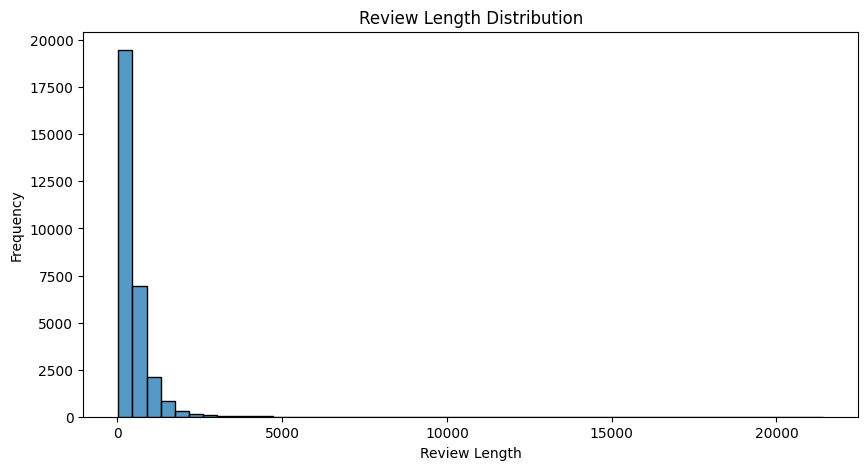

In [12]:
# Visualize review length distribution

plt.figure(figsize=(10,5))

sns.histplot(df['review_length'], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

In [13]:
# Reviews longer than 3000 characters

long_reviews = df[df['review_length'] > 3000]

print("Number of long reviews:")
print(long_reviews.shape[0])

long_reviews['sentiment'].value_counts()

Number of long reviews:
142


,count
sentiment,
negative,65
neutral,42
positive,35


# 🧹 Text Preprocessing

Raw customer reviews may contain inconsistent formatting, HTML tags, extra spaces, and unnecessary symbols.

In this step, we apply light text preprocessing to make the review text cleaner while preserving important sentiment meaning.

The cleaning strategy includes:

- Converting text to lowercase
- Removing HTML tags
- Removing URLs
- Removing unnecessary special characters
- Removing extra spaces

We avoid aggressive preprocessing such as stopword removal or stemming because words like "not" are important for sentiment analysis.

In [14]:
import re

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Keep letters, numbers, and basic spaces only
    text = re.sub(r"[^a-zA-Z0-9\s']", ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Apply text cleaning
df['clean_text'] = df['Text'].apply(clean_text)

# Compare original and cleaned text
df[['Text', 'clean_text', 'sentiment']].head()

,Text,clean_text,sentiment
0,I gave this to my sister-in-law for her birthd...,i gave this to my sister in law for her birthd...,positive
1,"When I was younger, I used to eat the Maple & ...",when i was younger i used to eat the maple bro...,negative
2,"I like the other two flavors, especially the B...",i like the other two flavors especially the bb...,negative
3,The first problem: There's only 3% juice! Unle...,the first problem there's only 3 juice unless ...,negative
4,"I don't drink coffee every day, more like once...",i don't drink coffee every day more like once ...,positive


# ✂️ Train-Test Split

Before training the machine learning model, we split the dataset into:

- Training set (80%) → used for learning patterns
- Testing set (20%) → used for evaluation

We use stratified sampling to preserve class balance across all sentiment categories.

In [15]:
from sklearn.model_selection import train_test_split

# Features and target
X = df['clean_text']
y = df['sentiment']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTrain sentiment distribution:")
print(y_train.value_counts())

print("\nTest sentiment distribution:")
print(y_test.value_counts())

Training samples: 24000
Testing samples: 6000

Train sentiment distribution:
sentiment
neutral     8000
positive    8000
negative    8000
Name: count, dtype: int64

Test sentiment distribution:
sentiment
negative    2000
positive    2000
neutral     2000
Name: count, dtype: int64


# 🔢 Text Vectorization using TF-IDF

Machine learning models cannot understand raw text directly.

To solve this, we convert customer reviews into numerical features using TF-IDF (Term Frequency - Inverse Document Frequency).

TF-IDF helps identify important words in each review while reducing the impact of common words.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

# Transform text into numerical features
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test set
X_test_tfidf = tfidf.transform(X_test)

# Check shape
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (24000, 10000)
Test shape: (6000, 10000)


# 🤖 Baseline Model Training — Logistic Regression

After converting text into TF-IDF numerical features, we train a baseline machine learning model.

For this project, Logistic Regression is used as the first model because it is:

- Fast and efficient
- Strong for text classification tasks
- Easy to interpret
- A reliable baseline before trying more advanced models

Although it has "Regression" in its name, Logistic Regression is commonly used for classification problems.

In [17]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

# 📊 Model Evaluation

After training the model, we evaluate its performance on unseen data (test set).

We will measure performance using:

- Accuracy Score
- Classification Report
- Confusion Matrix

These metrics help us understand how well the model predicts customer sentiment.

In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Generate predictions
y_pred = log_reg_model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy:
69.67 %

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.71      0.71      2000
     neutral       0.61      0.62      0.62      2000
    positive       0.77      0.76      0.76      2000

    accuracy                           0.70      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.70      0.70      0.70      6000


Confusion Matrix:
[[1421  450  129]
 [ 429 1237  334]
 [ 149  329 1522]]


# 📉 Confusion Matrix Visualization

A confusion matrix helps us visualize model predictions.

- Correct predictions appear on the diagonal
- Misclassifications appear outside the diagonal

This helps identify where the model struggles, especially between sentiment classes.

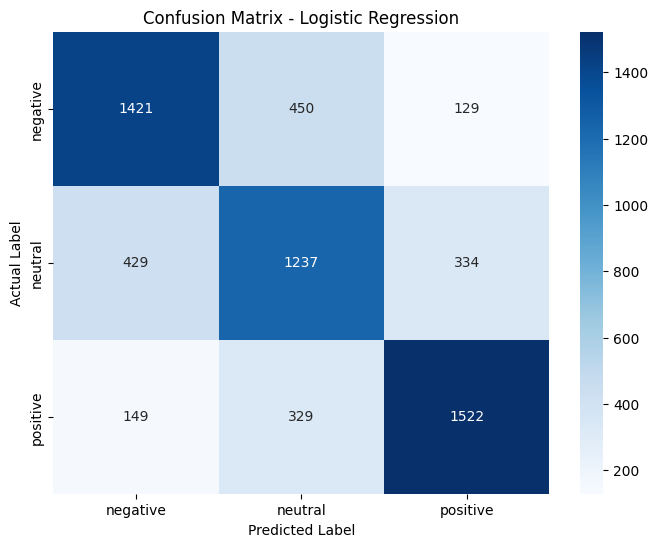

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# 🔁 Improving TF-IDF with Unigrams and Bigrams

The first TF-IDF model used single words only.

However, sentiment meaning often depends on word combinations such as:

- not good
- very bad
- highly recommend
- waste money

To capture these short phrases, we improve TF-IDF by using both:

- Unigrams: single words
- Bigrams: two-word combinations

This may help the model better understand sentiment context.

In [20]:
# Improved TF-IDF using unigrams and bigrams

tfidf_ngram = TfidfVectorizer(
    max_features=20000,
    stop_words='english',
    ngram_range=(1, 2)
)

# Transform text
X_train_tfidf_ngram = tfidf_ngram.fit_transform(X_train)
X_test_tfidf_ngram = tfidf_ngram.transform(X_test)

print("Train shape:", X_train_tfidf_ngram.shape)
print("Test shape:", X_test_tfidf_ngram.shape)

Train shape: (24000, 20000)
Test shape: (6000, 20000)


# 🤖 Improved Model Training — Logistic Regression with N-Gram TF-IDF

After improving TF-IDF by including both unigrams and bigrams, we train another Logistic Regression model.

The goal is to test whether capturing short word combinations improves sentiment classification performance.

In [21]:
# Train Logistic Regression using improved TF-IDF features

log_reg_ngram_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_ngram_model.fit(X_train_tfidf_ngram, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [22]:
# Predict using improved model

y_pred_ngram = log_reg_ngram_model.predict(X_test_tfidf_ngram)

# Evaluate improved model

accuracy_ngram = accuracy_score(y_test, y_pred_ngram)

print("Improved Model Accuracy:")
print(round(accuracy_ngram * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ngram))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ngram))

Improved Model Accuracy:
71.17 %

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.72      0.72      2000
     neutral       0.64      0.64      0.64      2000
    positive       0.78      0.78      0.78      2000

    accuracy                           0.71      6000
   macro avg       0.71      0.71      0.71      6000
weighted avg       0.71      0.71      0.71      6000


Confusion Matrix:
[[1434  430  136]
 [ 410 1276  314]
 [ 147  293 1560]]


# 🚀 Advanced Model Training — Linear SVM

After testing Logistic Regression as a baseline model, we try a more advanced model commonly used in NLP tasks.

Linear Support Vector Machine (Linear SVM) is known to perform very well on TF-IDF text features, especially in sentiment classification tasks.

In [23]:
from sklearn.svm import LinearSVC

# Create Linear SVM model
svm_model = LinearSVC(
    random_state=42
)

# Train model
svm_model.fit(X_train_tfidf_ngram, y_train)

LinearSVC(random_state=42)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred_svm = svm_model.predict(X_test_tfidf_ngram)

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:")
print(round(accuracy_svm * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy:
70.53 %

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.71      0.71      2000
     neutral       0.63      0.63      0.63      2000
    positive       0.77      0.78      0.77      2000

    accuracy                           0.71      6000
   macro avg       0.71      0.71      0.71      6000
weighted avg       0.71      0.71      0.71      6000


Confusion Matrix:
[[1420  442  138]
 [ 424 1262  314]
 [ 146  304 1550]]


# 📌 Baseline Model Comparison

After testing multiple classical machine learning models, we compare their performance to understand which approach performed best.

The tested models are:

- Logistic Regression with basic TF-IDF
- Logistic Regression with TF-IDF + Bigrams
- Linear SVM with TF-IDF + Bigrams

This comparison helps establish a baseline before moving to a transformer-based model.

In [25]:
# Create model comparison table

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression + TF-IDF",
        "Logistic Regression + TF-IDF + Bigrams",
        "Linear SVM + TF-IDF + Bigrams"
    ],
    "Accuracy": [
        accuracy,
        accuracy_ngram,
        accuracy_svm
    ]
})

# Convert accuracy to percentage
model_results["Accuracy (%)"] = (model_results["Accuracy"] * 100).round(2)

model_results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression + TF-IDF,0.696667,69.67
1,Logistic Regression + TF-IDF + Bigrams,0.711667,71.17
2,Linear SVM + TF-IDF + Bigrams,0.705333,70.53


## 📊 Model Comparison Insights

The best-performing classical machine learning model was:

**Logistic Regression + TF-IDF + Bigrams** with an accuracy of **71.17%**.

Adding bigrams slightly improved performance because the model could better capture short phrases such as:

- "not good"
- "very bad"
- "highly recommend"

Linear SVM produced similar results, which suggests that the main challenge may not be the model itself, but rather the difficulty of separating **neutral reviews**, since neutral sentiment is often ambiguous and overlaps with both positive and negative opinions.

# 🤗 Transformer Fine-Tuning — DistilBERT

After building classical machine learning baselines, we now fine-tune a transformer-based model.

We use DistilBERT because it is a lighter and faster version of BERT, making it suitable for experimentation on Google Colab.

Unlike TF-IDF models, DistilBERT learns contextual meaning from text, which may help improve sentiment classification, especially for more complex review language.

In [26]:
!pip install -q transformers datasets evaluate accelerate

In [27]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


# 🧾 Preparing Data for DistilBERT

Transformer models require labels to be represented as numbers instead of text.

We convert sentiment labels into numerical classes:

- negative → 0
- neutral → 1
- positive → 2

To keep training efficient on Google Colab, we fine-tune DistilBERT on a balanced sample of the dataset.

In [28]:
# Create label mapping

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

# Prepare transformer dataset
transformer_df = df[['clean_text', 'sentiment']].copy()

transformer_df['label'] = transformer_df['sentiment'].map(label2id)

transformer_df.head()

,clean_text,sentiment,label
0,i gave this to my sister in law for her birthd...,positive,2
1,when i was younger i used to eat the maple bro...,negative,0
2,i like the other two flavors especially the bb...,negative,0
3,the first problem there's only 3 juice unless ...,negative,0
4,i don't drink coffee every day more like once ...,positive,2


In [29]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Test tokenization
sample_text = transformer_df['clean_text'].iloc[0]

tokens = tokenizer(sample_text)

print("Original text:")
print(sample_text[:200])

print("\nToken IDs:")
print(tokens['input_ids'][:30])

print("\nAttention Mask:")
print(tokens['attention_mask'][:30])

Original text:
i gave this to my sister in law for her birthday and she loved it she called 1 day after she got it and had already tried 3 of the 4 teas she really liked them all the infuser worked great for her and

Token IDs:
[101, 1045, 2435, 2023, 2000, 2026, 2905, 1999, 2375, 2005, 2014, 5798, 1998, 2016, 3866, 2009, 2016, 2170, 1015, 2154, 2044, 2016, 2288, 2009, 1998, 2018, 2525, 2699, 1017, 1997]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [30]:
def tokenize_function(example):
    return tokenizer(
        example['clean_text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

In [31]:
from datasets import Dataset

# Convert pandas dataframe to Hugging Face dataset
dataset = Dataset.from_pandas(transformer_df)

# Apply tokenizer
tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenized_dataset

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Dataset({
    features: ['clean_text', 'sentiment', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30000
})

# 📏 Token Length Analysis

Before fine-tuning DistilBERT, we analyze the token length distribution of the reviews.

This helps us decide whether `max_length=128` is enough or whether a longer sequence length such as 256 may preserve more context.

In [32]:
# Calculate token length for each review without padding or truncation

transformer_df['token_length'] = transformer_df['clean_text'].apply(
    lambda x: len(tokenizer(x, truncation=False, padding=False)['input_ids'])
)

# Token length statistics
transformer_df['token_length'].describe()

Token indices sequence length is longer than the specified maximum sequence length for this model (515 > 512). Running this sequence through the model will result in indexing errors


,token_length
count,30000.000000
mean,99.640733
std,96.404559
min,7.000000
25%,43.000000
50%,72.000000
75%,122.000000
max,4025.000000


# ✂️ Train-Test Split for Transformer Dataset

After tokenizing the reviews, we split the dataset into training and testing sets.

The training set is used to fine-tune DistilBERT, while the test set is used to evaluate how well the model generalizes to unseen reviews.

In [33]:
# Train / Test split

tokenized_dataset = tokenized_dataset.train_test_split(
    test_size=0.2,
    seed=42
)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['clean_text', 'sentiment', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 24000
    })
    test: Dataset({
        features: ['clean_text', 'sentiment', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6000
    })
})

In [34]:
# Check label distribution

print("Train distribution:")
print(tokenized_dataset["train"].to_pandas()["label"].value_counts())

print("\nTest distribution:")
print(tokenized_dataset["test"].to_pandas()["label"].value_counts())

Train distribution:
label
0    8012
2    8012
1    7976
Name: count, dtype: int64

Test distribution:
label
1    2024
0    1988
2    1988
Name: count, dtype: int64


# 🚀 Fine-Tuning Configuration — DistilBERT

After loading the pretrained DistilBERT model, we configure the training process.

In this stage, we define how the model will learn from our Amazon review dataset, including:

- Number of training epochs
- Learning rate
- Batch size
- Evaluation strategy
- Model checkpoint saving

These settings control the balance between model performance, training stability, and computational efficiency.

In [35]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load pretrained model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [36]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=4,

    weight_decay=0.01,

    logging_dir="./logs",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none"
)

training_args

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

# 🧠 Trainer Setup with Early Stopping

In this step, we create the Hugging Face Trainer.

The Trainer connects:

- The DistilBERT model
- Training arguments
- Training dataset
- Evaluation dataset
- Evaluation metrics
- Early stopping callback

This allows us to fine-tune the transformer model and monitor performance after each epoch.

In [37]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [38]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=1)
    ]
)

trainer

In [39]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.659703,0.592273,0.743833,0.748474,0.744551,0.744577
2,0.470020,0.625093,0.748333,0.765010,0.748252,0.746415


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.564861328125, metrics={'train_runtime': 629.4105, 'train_samples_per_second': 152.524, 'train_steps_per_second': 9.533, 'total_flos': 1589637132288000.0, 'train_loss': 0.564861328125, 'epoch': 2.0})

## 🤗 Transformer Model Insights

DistilBERT achieved the best overall performance compared to the classical machine learning models used in this project.

The model achieved its strongest performance with an accuracy of approximately **74.40%** and an F1-score of approximately **74.9%**, outperforming all TF-IDF-based approaches.

Training progressed for two epochs. While the training loss continued to decrease, validation performance showed only limited improvement, suggesting that additional training may not significantly improve generalization and could increase the risk of overfitting.

Because early stopping and best model loading were enabled, the model automatically retained the strongest checkpoint during training.

These findings suggest that transformer-based architectures are better at capturing contextual meaning in customer reviews compared to traditional TF-IDF methods. However, **neutral sentiment remained the most challenging category** due to semantic ambiguity and overlap with both positive and negative opinions.

# 📊 Final Evaluation — DistilBERT

After fine-tuning DistilBERT, we evaluate its performance on the unseen test dataset.

We generate:

- Classification Report
- Confusion Matrix
- Accuracy score

This helps compare transformer performance with traditional machine learning models.

In [40]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Predictions on test set
predictions = trainer.predict(tokenized_dataset["test"])

# Get predicted labels
y_pred_transformer = np.argmax(predictions.predictions, axis=1)

# True labels
y_true_transformer = predictions.label_ids

# Accuracy
accuracy_transformer = accuracy_score(
    y_true_transformer,
    y_pred_transformer
)

print("DistilBERT Accuracy:")
print(round(accuracy_transformer * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_true_transformer,
    y_pred_transformer,
    target_names=["negative", "neutral", "positive"]
))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(
    y_true_transformer,
    y_pred_transformer
))

DistilBERT Accuracy:
74.4 %

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.81      0.76      1988
     neutral       0.66      0.63      0.64      2024
    positive       0.88      0.80      0.84      1988

    accuracy                           0.74      6000
   macro avg       0.75      0.74      0.74      6000
weighted avg       0.75      0.74      0.74      6000


Confusion Matrix:
[[1612  332   44]
 [ 579 1266  179]
 [  85  317 1586]]


# 📈 Final Model Comparison

We compare classical machine learning models with the transformer-based model.

The goal is to evaluate whether contextual language understanding improves sentiment classification performance.

In [41]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression + TF-IDF",
        "Logistic Regression + TF-IDF + Bigrams",
        "Linear SVM + TF-IDF + Bigrams",
        "DistilBERT Fine-Tuning"
    ],

    "Accuracy (%)": [
        round(accuracy * 100, 2),
        round(accuracy_ngram * 100, 2),
        round(accuracy_svm * 100, 2),
        round(accuracy_transformer * 100, 2)
    ]
})

final_results = final_results.sort_values(
    by="Accuracy (%)",
    ascending=False
)

final_results

,Model,Accuracy (%)
3,DistilBERT Fine-Tuning,74.40
1,Logistic Regression + TF-IDF + Bigrams,71.17
2,Linear SVM + TF-IDF + Bigrams,70.53
0,Logistic Regression + TF-IDF,69.67


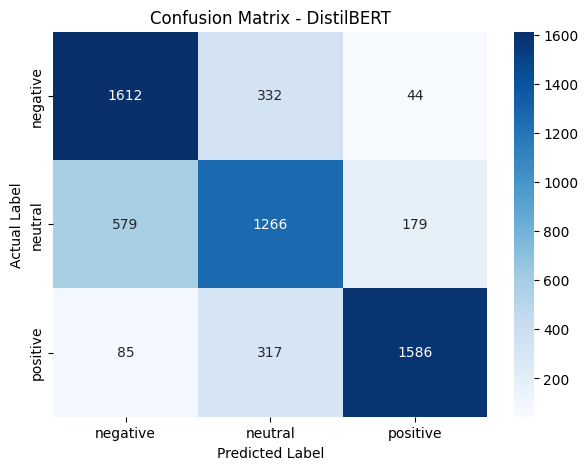

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm_transformer = confusion_matrix(
    y_true_transformer,
    y_pred_transformer
)

# Plot
plt.figure(figsize=(7,5))

sns.heatmap(
    cm_transformer,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - DistilBERT")

plt.show()

# Conclusion

This project explored sentiment analysis on Amazon product reviews using both traditional machine learning techniques and transformer-based deep learning approaches.

The project began with classical NLP methods using TF-IDF vectorization combined with Logistic Regression and Linear SVM models to establish strong baseline performance. Feature engineering through bigrams improved contextual understanding, resulting in better predictive performance compared to standard unigram representations. Among traditional machine learning approaches, Logistic Regression with TF-IDF + Bigrams achieved the strongest baseline accuracy of approximately 71%.

To further improve sentiment classification performance, a transformer-based approach was introduced through DistilBERT fine-tuning. Unlike traditional methods that depend on manually engineered text representations, DistilBERT utilizes contextual embeddings to better understand semantic relationships and language patterns within customer reviews.

The fine-tuned DistilBERT model achieved the best overall performance with an accuracy of **74.40%**, outperforming all traditional machine learning models in this project. This demonstrates the effectiveness of transformer architectures in capturing contextual meaning and handling complex language structures more effectively than conventional NLP approaches.

Performance analysis showed noticeable variation across sentiment categories. Positive reviews achieved the strongest classification performance, suggesting that explicit positive language is easier for the model to identify. Negative reviews also showed relatively strong performance. However, neutral sentiment remained the most challenging category due to its ambiguous nature and semantic overlap with both positive and negative opinions. Confusion matrix analysis revealed that many neutral reviews were frequently misclassified into neighboring sentiment categories, highlighting a common challenge in real-world sentiment analysis tasks.

From a business perspective, these findings demonstrate how transformer-based NLP models can improve automated customer feedback analysis for e-commerce platforms. Such systems can help businesses monitor customer satisfaction, detect recurring product issues, identify dissatisfaction patterns, and better understand customer perception at scale.

Although DistilBERT delivered superior predictive performance, it also introduced higher computational requirements compared to classical machine learning approaches. Therefore, selecting an appropriate model in production environments should consider the trade-off between predictive accuracy, computational cost, and scalability.

Future improvements could include experimenting with larger transformer models such as BERT or RoBERTa, performing hyperparameter optimization, refining sequence length selection, and exploring binary sentiment classification to reduce ambiguity surrounding neutral sentiment. Additional domain-specific fine-tuning and advanced preprocessing techniques may further improve performance.

Overall, this project demonstrates a complete end-to-end NLP workflow for sentiment classification, combining traditional machine learning, transformer fine-tuning, performance evaluation, and business-oriented interpretation to solve a real-world customer feedback problem.